In [3]:
import numpy as np
import pandas as pd

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df_train = pd.read_csv('D:\\repos\\ML_innovise\\data\\processed\\df_train_eda.csv')
df_test = pd.read_csv('D:\\repos\\ML_innovise\\data\\processed\\df_test_eda.csv')

In [6]:
from sklearn.linear_model import LinearRegression

modelLR = LinearRegression(fit_intercept=True, n_jobs=-1)



Перед тем, как обучать, есть вещи, на которые линейная регрессия смотрит ну очень пристально:
- мультиколлинеарность
Поэтому построим hit_map

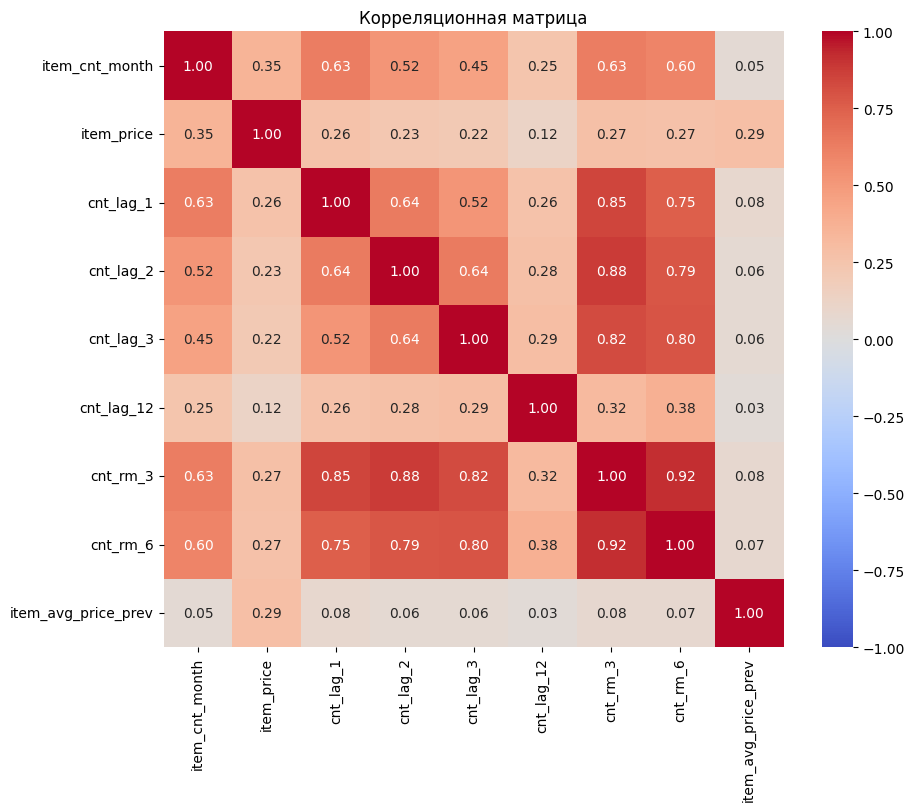

In [16]:
cols = [
    'item_cnt_month',
    'item_price',
    'cnt_lag_1',
    'cnt_lag_2',
    'cnt_lag_3',
    'cnt_lag_12',
    'cnt_rm_3',
    'cnt_rm_6',
    'item_avg_price_prev'
]
corr = df_train[cols].corr()
plt.figure(figsize=(10, 8))

sns.heatmap(corr, annot = True, fmt = '.2f', cmap = 'coolwarm', vmin = -1, vmax = 1)
plt.title('Корреляционная матрица')
plt.show()


Видим мультиколлинераность между: cnt_lag_1 и cnt_rm_3 - оставлю cnt_lag_1

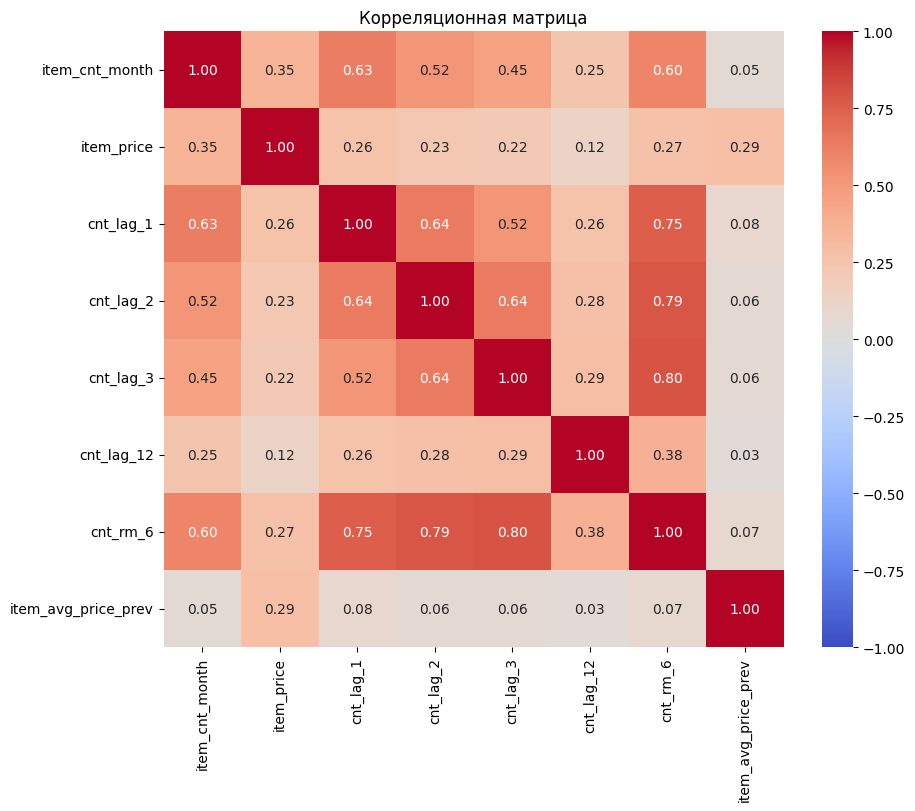

In [17]:
cols = [
    'item_cnt_month',
    'item_price',
    'cnt_lag_1',
    'cnt_lag_2',
    'cnt_lag_3',
    'cnt_lag_12',
    'cnt_rm_6',
    'item_avg_price_prev'
]
corr = df_train[cols].corr()
plt.figure(figsize = (10,8))
sns.heatmap(corr, annot = True, fmt = '.2f', cmap = 'coolwarm', vmin = -1, vmax = 1)
plt.title("Корреляционная матрица")
plt.show()

Поскольку здесь признаков мало и хочелось побольше сохранить - я считаю, что порог такой: 

все признаки,у кот корреляция выше 0.8 - скоррелированы. Таких больше нет, значит можем обучать.

In [18]:
from Splitter import Splitter

splitter = Splitter('date_block_num', 33)

In [21]:
from Validator import Validator
from sklearn.metrics import mean_squared_error
from math import sqrt

validator = Validator(df_train, splitter, modelLR, metric   = lambda y, yhat: sqrt(mean_squared_error(y, yhat)))
features =['cnt_lag_1','cnt_lag_3','cnt_lag_2','cnt_lag_12','cnt_rm_6','item_avg_price_prev', 'item_price','date_block_num','avg_price_prev_missing']
result = validator.run(features, 'item_cnt_month')
print('Val_score_RMSE:', result)


Val_score_RMSE: {'val_score': 0.9031100471569982, 'pred_val': array([0.05886432, 0.23518083, 0.24958519, ..., 0.19882514, 0.05369259,
       0.05369259], shape=(214200,))}


In [22]:
df_testt = pd.read_csv(r'D:\ML_innovise\test.csv')
df_test = df_test.merge(
    df_testt,
    on = ['shop_id','item_id'],
    how = 'left'
)

In [24]:
X_tr, y_tr, X_val, y_val = splitter.split(df_train, features,'item_cnt_month')
X_tr_full = pd.concat([X_tr, X_val], axis = 0)
y_tr_full = pd.concat([y_tr, y_val])
modelLR.fit(X_tr_full, y_tr_full)
X_test = df_test[features]
pred = modelLR.predict(X_test)



In [25]:
submission = pd.DataFrame({
    "ID":              df_test["ID"],
    "item_cnt_month":  pred
})



In [27]:
submission.to_csv("submissionLR.csv", index=False)

результат на кагле - 1.03054
Теперь хочу попробовать, а если перед тем, как подавать данные модели их масштабирую -  что будет?